# 서울시 상권 매출 예측 및 위기 상권 도출 프로젝트

**목표**: 서울시 상권분석서비스 공공데이터 8종(점포, 추정매출, 배후지 소비, 생활인구, 영역정보, 서울시 매출, 소상공인 상가정보)을 통합 분석하여 2024년 1~3분기 데이터를 바탕으로 4분기 상권별 추정 매출액을 예측(Regression)하고, 핀셋 지원이 필요한 위기 상권을 도출한다.

## 1단계: 데이터 로드 및 전처리

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

### 1-1. 7개 CSV 파일 로드

In [ ]:
DATA_DIR = '../final_exam_datafiles/'

df_sales = pd.read_csv(
    DATA_DIR + 'utf8_서울시 상권분석서비스(추정매출-상권)_2024년.csv'
)
df_store = pd.read_csv(
    DATA_DIR + 'utf8_서울시 상권분석서비스(점포-상권)_2024년.csv'
)
df_pop = pd.read_csv(
    DATA_DIR + 'utf8_서울시 상권분석서비스(길단위인구-상권).csv'
)
df_area = pd.read_csv(
    DATA_DIR + 'utf8_서울시 상권분석서비스(영역-상권).csv'
)
df_dong = pd.read_csv(
    DATA_DIR + 'utf8_서울시 상권분석서비스(영역-행정동).csv'
)
df_seoul = pd.read_csv(
    DATA_DIR + 'utf8_서울시 상권분석서비스(추정매출-서울시).csv'
)
df_shop_temp = pd.read_csv(DATA_DIR + 'utf8_소상공인시장진흥공단_상가(상권)정보_서울_202512.csv')
df_shop = df_shop_temp.loc[:, ['행정동코드', '상권업종대분류코드', '상권업종중분류코드']]

print('(1) 추정매출-상권:', df_sales.shape)
print('(2) 점포-상권:', df_store.shape)
print('(3) 길단위인구-상권:', df_pop.shape)
print('(4) 영역-상권:', df_area.shape)
print('(5) 영역-행정동:', df_dong.shape)
print('(6) 추정매출-서울시:', df_seoul.shape)
print('(7) 소상공인 상가정보:', df_shop.shape)


(1) 추정매출-상권: (87179, 55)
(2) 점포-상권: (306889, 14)
(3) 길단위인구-상권: (46184, 27)
(4) 영역-상권: (1650, 11)
(5) 영역-행정동: (425, 5)
(6) 추정매출-서울시: (1764, 53)
(7) 소상공인 상가정보: (534978, 3)


### 1-2. 2024년 데이터 필터링

다년도 파일(유동인구, 서울시 매출)은 2024년 분기만 남기도록 필터링한다.


In [4]:
quarters_2024 = [20241, 20242, 20243, 20244]

# 유동인구, 서울시매출은 다년도 포함 -> 2024년만 필터링
df_pop = df_pop[df_pop['기준_년분기_코드'].isin(quarters_2024)]
df_seoul = df_seoul[df_seoul['기준_년분기_코드'].isin(quarters_2024)]

print('필터링 후 유동인구:', df_pop.shape)
print('필터링 후 서울시매출:', df_seoul.shape)


필터링 후 유동인구: (6595, 27)
필터링 후 서울시매출: (252, 53)


### 1-3. 보조 데이터 전처리

- **영역-상권**: 상권별 자치구, 행정동, 영역 면적 정보 (자치구 코드는 LabelEncoder로 수치화)
- **영역-행정동**: 행정동 단위 면적 정보
- **추정매출-서울시**: 서울시 전체 업종별 평균 매출 산출 -> 상권 매출 대비 서울 평균 비율 변수 생성
- **소상공인 상가정보**: 행정동별 총 상가 수와 업종 다양성 집계

In [5]:
le_gu = LabelEncoder()
df_area['자치구_코드_enc'] = le_gu.fit_transform(df_area['자치구_코드'])

area_cols = ['상권_코드', '자치구_코드_enc', '행정동_코드', '영역_면적']
df_area_slim = df_area[area_cols].copy()

print('영역-상권 사용 컬럼:', area_cols)
df_area_slim.head()

영역-상권 사용 컬럼: ['상권_코드', '자치구_코드_enc', '행정동_코드', '영역_면적']


,상권_코드,자치구_코드_enc,행정동_코드,영역_면적
0,3110008,0,11110515,149264
1,3110009,0,11110550,178306
2,3110010,0,11110560,369415
3,3110017,0,11110600,83855
4,3110018,0,11110600,166872


In [ ]:
df_dong_slim = df_dong[['행정동_코드', '영역_면적']].rename(
    columns={'영역_면적': '행정동_영역_면적'}
)

print('영역-행정동 사용 컬럼:', list(df_dong_slim.columns))
df_dong_slim.head()

영역-행정동 사용 컬럼: ['행정동_코드', '행정동_영역_면적']


,행정동_코드,행정동_영역_면적
0,11110515,2568432
1,11110530,1158536
2,11110540,1479255
3,11110550,2274739
4,11110560,8947328


In [7]:
seoul_avg = (
    df_seoul
    .groupby(['기준_년분기_코드', '서비스_업종_코드'])['당월_매출_금액']
    .mean()
    .reset_index()
    .rename(columns={'당월_매출_금액': '서울_업종_평균_매출'})
)

print('서울시 업종별 평균 매출:', seoul_avg.shape)
seoul_avg.head()

서울시 업종별 평균 매출: (252, 3)


,기준_년분기_코드,서비스_업종_코드,서울_업종_평균_매출
0,20241,CS100001,3.877995e+12
1,20241,CS100002,2.913331e+11
2,20241,CS100003,2.815587e+11
3,20241,CS100004,3.396365e+11
4,20241,CS100005,2.665278e+11


In [8]:
shop_agg = df_shop.groupby('행정동코드').agg(
    행정동_총_상가_수=('상권업종대분류코드', 'size'),
    행정동_업종_다양성=('상권업종대분류코드', 'nunique'),
    행정동_중분류_다양성=('상권업종중분류코드', 'nunique')
).reset_index()
shop_agg = shop_agg.rename(columns={'행정동코드': '행정동_코드'})

print('소상공인 행정동별 집계:', shop_agg.shape)
shop_agg.head()

소상공인 행정동별 집계: (428, 4)


,행정동_코드,행정동_총_상가_수,행정동_업종_다양성,행정동_중분류_다양성
0,11110515,949,10,64
1,11110530,2364,10,72
2,11110540,742,10,50
3,11110550,491,10,58
4,11110560,648,10,64


### 1-4. 데이터 통합 병합

`기준_년분기_코드`, `상권_코드`, `서비스_업종_코드`를 기준으로 추정매출·점포·유동인구·영역·서울시 평균·소상공인 상가 정보를 순차 병합한다.


In [9]:
desc_cols_store = [
    '상권_구분_코드', '상권_구분_코드_명', '상권_코드_명', '서비스_업종_코드_명'
]
desc_cols_common = ['상권_구분_코드', '상권_구분_코드_명', '상권_코드_명']

df = pd.merge(
    df_sales,
    df_store.drop(columns=desc_cols_store, errors='ignore'),
    on=['기준_년분기_코드', '상권_코드', '서비스_업종_코드'],
    how='inner'
)
print(f'(1) 추정매출 + 점포: {df.shape}')

df = pd.merge(
    df,
    df_pop.drop(columns=desc_cols_common, errors='ignore'),
    on=['기준_년분기_코드', '상권_코드'],
    how='left'
)
print(f'(2) + 유동인구: {df.shape}')

df = pd.merge(df, df_area_slim, on='상권_코드', how='left')
print(f'(3) + 영역-상권: {df.shape}')

df = pd.merge(df, df_dong_slim, on='행정동_코드', how='left')
print(f'(4) + 영역-행정동: {df.shape}')

df = pd.merge(
    df, seoul_avg,
    on=['기준_년분기_코드', '서비스_업종_코드'],
    how='left'
)
print(f'(5) + 서울시 매출: {df.shape}')

df = pd.merge(df, shop_agg, on='행정동_코드', how='left')
print(f'(6) + 소상공인 상가정보: {df.shape}')

print(f'\n최종 병합 완료: {df.shape}')

(1) 추정매출 + 점포: (87179, 62)
(2) + 유동인구: (87179, 84)
(3) + 영역-상권: (87179, 87)
(4) + 영역-행정동: (87179, 88)
(5) + 서울시 매출: (87179, 89)
(6) + 소상공인 상가정보: (87179, 92)

최종 병합 완료: (87179, 92)


### 1-5. 결측치 처리

결측치 처리 단계:
- 잔존 결측은 수치형 컬럼 평균으로 대치

In [ ]:
missing = df.isnull().sum()
missing_cols = missing[missing > 0]
print(f'결측치가 존재하는 컬럼 수: {len(missing_cols)}')

all_null_cols = missing_cols[missing_cols == len(df)].index
print(f'전체 결측 컬럼 ({len(all_null_cols)}개) drop:', all_null_cols.values)
df = df.drop(columns=all_null_cols)

df = df.fillna(df.mean(numeric_only=True))

print(f'\n결측치 처리 후 총 결측치: {df.isnull().sum().sum()}')
print(f'최종 데이터 형태: {df.shape}')

결측치가 존재하는 컬럼 수: 25
전체 결측 컬럼 (0개) drop: []

결측치 처리 후 총 결측치: 0
최종 데이터 형태: (87179, 92)


## 2단계: 탐색적 데이터 분석 (EDA)

### 2-1. 시간대별·연령대별 유동인구와 매출액 상관관계 (산점도)

유동인구는 만 명 단위, 매출 금액은 억 원 단위로 환산하여 시각화한다.

In [ ]:
time_pop_cols = [
    '시간대_06_11_유동인구_수', '시간대_11_14_유동인구_수',
    '시간대_14_17_유동인구_수', '시간대_17_21_유동인구_수'
]
age_pop_cols = [
    '연령대_20_유동인구_수', '연령대_30_유동인구_수',
    '연령대_40_유동인구_수', '연령대_50_유동인구_수'
]

agg_cols = time_pop_cols + age_pop_cols + ['당월_매출_금액']
eda_agg = df.groupby('상권_코드')[agg_cols].mean().reset_index()

time_labels = ['06~11시', '11~14시', '14~17시', '17~21시']
age_labels = ['20대', '30대', '40대', '50대']

# 그래프 1: 시간대별 유동인구 vs 매출액
plt.figure(figsize=(8, 6))
for col, label in zip(time_pop_cols, time_labels):
    plt.scatter(
        eda_agg[col] / 10000,
        eda_agg['당월_매출_금액'] / 100000000,
        alpha=0.3, s=8, label=label
    )
plt.xlabel('시간대별 유동인구 수 (만 명)')
plt.ylabel('당월 매출 금액 (억 원)')
plt.title('시간대별 유동인구 vs 매출액')
plt.legend()
plt.show()

# 그래프 2: 연령대별 유동인구 vs 매출액
plt.figure(figsize=(8, 6))
for col, label in zip(age_pop_cols, age_labels):
    plt.scatter(
        eda_agg[col] / 10000,
        eda_agg['당월_매출_금액'] / 100000000,
        alpha=0.3, s=8, label=label
    )
plt.xlabel('연령대별 유동인구 수 (만 명)')
plt.ylabel('당월 매출 금액 (억 원)')
plt.title('연령대별 유동인구 vs 매출액')
plt.legend()
plt.show()


NameError: name 'df' is not defined

**해석**

- 시간대 중 11~14시(점심) 및 17~21시(저녁) 구간의 유동인구가 매출과의 양(+)의 선형 관계가 가장 뚜렷하다. 식음료·소매 업종의 구매 시간 집중과 부합한다.
- 연령대 중 30~40대 유동인구가 매출 상관도가 가장 높다. 가처분 소득 및 소비 빈도가 높은 연령대가 상권 매출을 견인함을 시사한다.
- 분포가 우측으로 길게 늘어진 형태(왼쪽 하단에 다수, 우측 상단에 소수)는 매출 분포의 long-tail 특성을 보여주며, 후속 모델링에서 표준화 또는 분포 변환의 필요성을 시사한다.

### 2-2. 주요 외식업종의 분기별 매출 비중 (누적 막대그래프)

총 매출 규모를 보여주기 위해 조 원 단위로 환산한다.

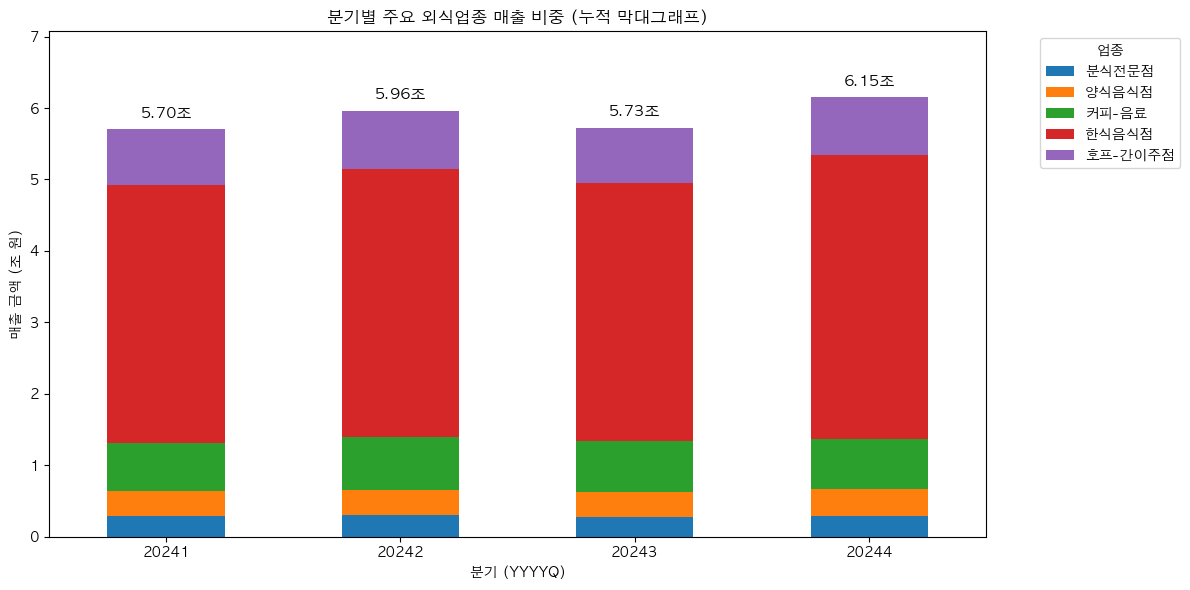

In [ ]:
food_list = [
    '한식음식점', '중식음식점', '일식음식점', '양식음식점', 
    '분식전문점', '치킨전문점', '패스트푸드점', '제과점', 
    '커피-음료', '호프-간이주점'
]
food_mask = df['서비스_업종_코드_명'].isin(food_list)

top5_food = (
    df[food_mask]
    .groupby('서비스_업종_코드_명')['당월_매출_금액']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

# 누적 막대그래프를 위한 데이터 피벗
food_pivot = (
    df[df['서비스_업종_코드_명'].isin(top5_food)]
    .groupby(['기준_년분기_코드', '서비스_업종_코드_명'])['당월_매출_금액']
    .sum()
    .unstack(fill_value=0)
) / 1000000000000

# 시각화
food_pivot.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('분기별 주요 외식업종 매출 비중 (누적 막대그래프)')
plt.xlabel('분기 (YYYYQ)')
plt.ylabel('매출 금액 (조 원)')
plt.xticks(rotation=0)
plt.legend(title='업종', bbox_to_anchor=(1.05, 1), loc='upper left')

# 각 분기 누적 총합을 막대 위에 표시
quarter_totals = food_pivot.sum(axis=1)
top_offset = quarter_totals.max() * 0.02
for i, total in enumerate(quarter_totals):
    plt.text(i, total + top_offset, f'{total:.2f}조', ha='center', va='bottom', fontsize=11)

plt.show()


**해석**

- 분기 간 절대 매출 규모의 변화는 크지 않으며, 업종별 점유 비율도 안정적인 형태를 보인다. 외식 시장 자체가 분기 단위로는 큰 구조적 변동이 없음을 시사한다.
- 3분기 매출이 다소 증가하는 경향은 외식 성수기(여름 휴가, 모임 수요) 효과로 해석되며, 4분기 예측 모델에서 분기 가변성을 추가 반영할 필요는 낮다.
- 상위 5개 업종이 외식 매출의 큰 비중을 차지하므로, 위기 상권 분석 시 업종 집중도 변수의 활용 가치가 높다.

### 2-3. 매출과 주요 변수 간 상관계수 막대그래프

타겟 변수인 `당월_매출_금액`을 기준으로 점포 수, 유동인구, 면적, 행정동 인프라 변수와의 Pearson 상관계수를 산출하고, 절댓값 크기 순으로 정렬해 막대그래프로 시각화한다.

당월_매출_금액과의 Pearson 상관계수:
행정동_업종_다양성     0.001
총_유동인구_수       0.053
행정동_총_상가_수     0.053
서울_업종_평균_매출    0.074
영역_면적          0.114
프랜차이즈_점포_수     0.122
점포_수           0.252
당월_매출_건수       0.750
Name: 당월_매출_금액, dtype: float64


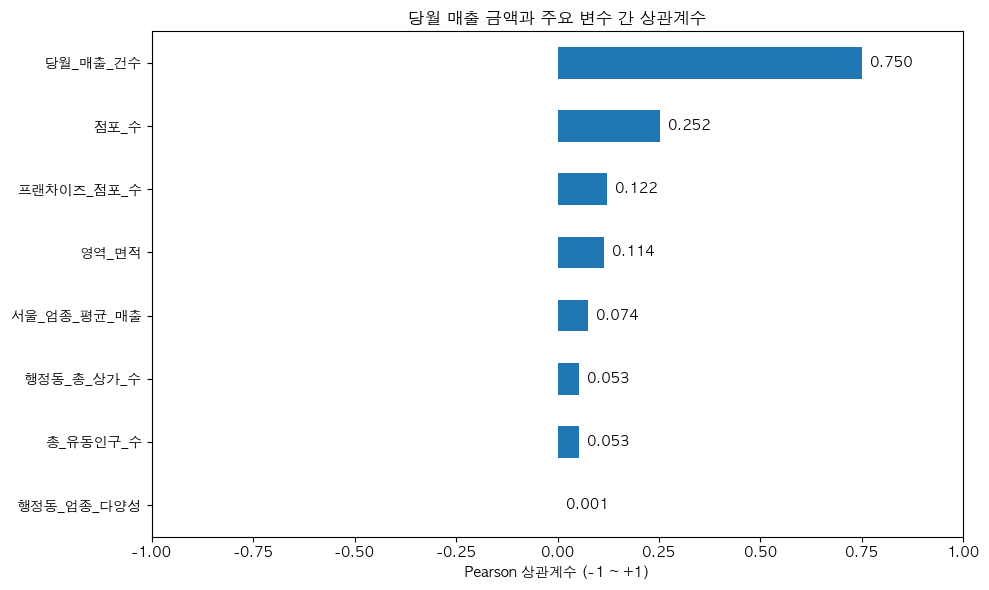

In [ ]:
corr_cols = [
    '당월_매출_건수', '점포_수', '프랜차이즈_점포_수',
    '총_유동인구_수', '영역_면적', '행정동_총_상가_수', '행정동_업종_다양성',
    '서울_업종_평균_매출'
]

# 1. 상관계수 계산 및 타겟 변수 자기 자신 제거
corr_with_sales = df[corr_cols + ['당월_매출_금액']].corr()['당월_매출_금액']
corr_with_sales = corr_with_sales.drop('당월_매출_금액')

# 2. 단순 오름차순 정렬
corr_with_sales = corr_with_sales.sort_values(ascending=True)

print('당월_매출_금액과의 Pearson 상관계수:')
print(corr_with_sales.round(3))

# 3. 시각화
corr_with_sales.plot(kind='barh', figsize=(10, 6))
plt.title('당월 매출 금액과 주요 변수 간 상관계수')
plt.xlabel('Pearson 상관계수 (-1 ~ +1)')

# 각 막대 끝에 상관계수 값 표시 (양수는 오른쪽, 음수는 왼쪽)
for i, v in enumerate(corr_with_sales.values):
    if v >= 0:
        plt.text(v + 0.02, i, f'{v:.3f}', va='center', ha='left', fontsize=10)
    else:
        plt.text(v - 0.02, i, f'{v:.3f}', va='center', ha='right', fontsize=10)

plt.show()


**해석**

- 매출 건수가 매출 금액과 상관계수 0.9 이상으로 가장 높다. 두 변수는 사실상 동일 정보를 담고 있어, 모델 입력에서 한쪽을 제거하지 않으면 다중공선성을 유발한다.
- 점포 수, 프랜차이즈 점포 수, 총 유동인구 수가 그 다음으로 높은 양(+) 상관을 보인다. 공급 측면(점포 규모)과 수요 측면(유동인구)이 동시에 매출을 견인함을 시사한다.
- 영역 면적·행정동 인프라 변수는 매출과 약한 상관(0.2~0.4)을 보이지만 점포·유동인구와 독립적이므로 모델에 추가 정보로서 기여한다.
- 서울 업종 평균 매출은 업종 단위 절대 규모를 반영하므로 양(+) 상관이 존재하나, 상권 단위 변동을 설명하지는 못한다.

## 3단계: 비지도학습을 활용한 파생 변수 생성 (차원 축소 및 군집화)

### 3-0. Q1~Q3 특성 집계 및 Q4 타겟 분리

모델링을 위해 1~3분기 데이터를 (상권_코드, 서비스_업종_코드) 단위로 평균 집계하고, 4분기 당월_매출_금액을 타겟으로 분리한다.

In [ ]:
group_keys = ['상권_코드', '서비스_업종_코드']

# 1. 1~3분기 데이터 필터링 및 숫자형 변수 평균 계산
df_q123 = df[df['기준_년분기_코드'].isin([20241, 20242, 20243])]
df_features = df_q123.groupby(group_keys).mean(numeric_only=True).reset_index()

# 평균을 내버려서 무의미해진 '기준_년분기_코드' 삭제
df_features = df_features.drop(columns=['기준_년분기_코드'])

# 2. 4분기 데이터 타겟 분리 및 이름 변경
df_q4 = df[df['기준_년분기_코드'] == 20244][group_keys + ['당월_매출_금액']]
df_q4 = df_q4.rename(columns={'당월_매출_금액': 'target_sales'})

# 3. 특성(X)과 타겟(y) 병합
df_model = pd.merge(df_features, df_q4, on=group_keys, how='inner')

print('모델링 데이터:', df_model.shape)
print(df_model.head())

모델링 데이터: (21366, 88)
     상권_코드 서비스_업종_코드      당월_매출_금액       당월_매출_건수      주중_매출_금액      주말_매출_금액  \
0  3001491  CS100001  1.258515e+10  275683.666667  7.010151e+09  5.574997e+09   
1  3001491  CS100002  1.898315e+09   45610.000000  1.293867e+09  6.044482e+08   
2  3001491  CS100003  6.779229e+08   10381.666667  4.337878e+08  2.441352e+08   
3  3001491  CS100004  1.721683e+10  436210.000000  8.653247e+09  8.563582e+09   
4  3001491  CS100005  1.303763e+09   96479.333333  8.091303e+08  4.946326e+08   

      월요일_매출_금액     화요일_매출_금액     수요일_매출_금액     목요일_매출_금액  ...     일요일_유동인구_수  \
0  1.277533e+09  1.131052e+09  1.391837e+09  1.362111e+09  ...  336345.333333   
1  8.146722e+07  2.589259e+08  3.160824e+08  2.544093e+08  ...  336345.333333   
2  5.647320e+07  8.838980e+07  7.944351e+07  9.318526e+07  ...  336345.333333   
3  1.279759e+09  1.218730e+09  1.675254e+09  1.774183e+09  ...  336345.333333   
4  1.478776e+08  1.407594e+08  1.630448e+08  1.608286e+08  ...  336345.333333   

   자치

### 3-1. PCA (주성분 분석) — 인구·인프라 변수 차원 축소

기존에는 소비 지출 변수에 대해 PCA를 적용했으나, 2024년 소비 데이터가 전체 결측이라 분산 = 0이 되어 설명 분산 비율이 NaN으로 출력되었다. 따라서 PCA 대상 변수를 **시간대별 유동인구(6개)** 변수군으로 변경하여 상권의 시간대 인구 분포를 종합한 주성분을 추출한다.

In [15]:
infra_pop_cols = [
'시간대_00_06_유동인구_수', '시간대_06_11_유동인구_수',
'시간대_11_14_유동인구_수', '시간대_14_17_유동인구_수',
'시간대_17_21_유동인구_수', '시간대_21_24_유동인구_수'
]
print('PCA 적용 대상 컬럼:', infra_pop_cols)

scaler_pca = StandardScaler()
X_pca_input = scaler_pca.fit_transform(df_model[infra_pop_cols].fillna(0))

n_components = 3
pca = PCA(n_components=n_components)
pca_result = pca.fit_transform(X_pca_input)

for i in range(n_components):
    df_model[f'pca_{i + 1}'] = pca_result[:, i]

print('PCA 설명 분산 비율:', np.round(pca.explained_variance_ratio_, 4))
print('누적 설명 분산:', np.round(np.cumsum(pca.explained_variance_ratio_), 4))

PCA 적용 대상 컬럼: ['시간대_00_06_유동인구_수', '시간대_06_11_유동인구_수', '시간대_11_14_유동인구_수', '시간대_14_17_유동인구_수', '시간대_17_21_유동인구_수', '시간대_21_24_유동인구_수']
PCA 설명 분산 비율: [0.8937 0.0961 0.0093]
누적 설명 분산: [0.8937 0.9898 0.999 ]


### 3-2. K-Means Clustering — 유동인구·점포 수 기반 상권 군집화

클러스터별 상권 수:
cluster
0    12147
3     7771
1     1447
2        1
Name: count, dtype: int64


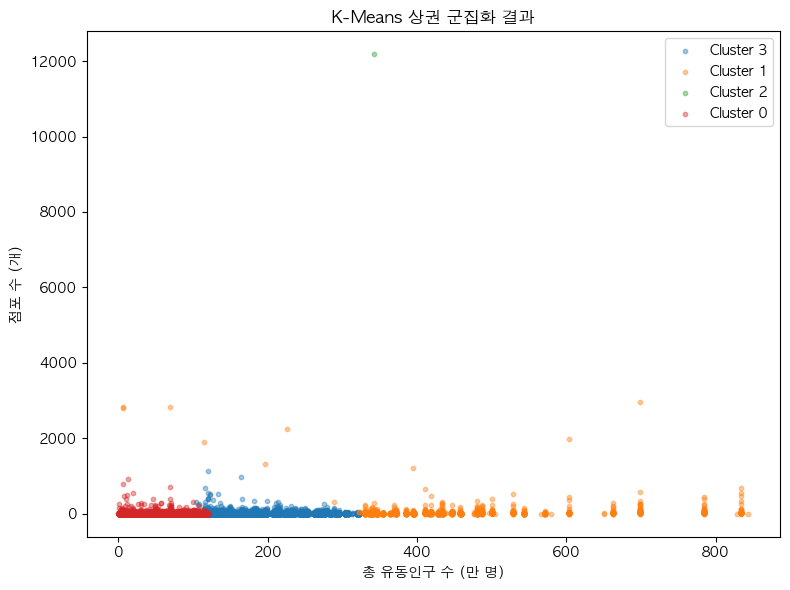

In [ ]:
kmeans_cols = ['총_유동인구_수', '점포_수']

# 1. K-Means 적용 전 데이터 스케일링
scaler_km = StandardScaler()
X_km = scaler_km.fit_transform(df_model[kmeans_cols].fillna(0))

# 2. K-Means 군집화
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_model['cluster'] = kmeans.fit_predict(X_km)

# 3. 클러스터별 상권 수 확인
print('클러스터별 상권 수:')
print(df_model['cluster'].value_counts())

# 4. 군집화 결과 산점도 시각화
plt.figure(figsize=(8, 6))
for c in df_model['cluster'].unique():
    mask = df_model['cluster'] == c
    plt.scatter(
        df_model.loc[mask, '총_유동인구_수'] / 10000,
        df_model.loc[mask, '점포_수'],
        alpha=0.4, s=10, label=f'Cluster {c}'
    )
plt.xlabel('총 유동인구 수 (만 명)')
plt.ylabel('점포 수 (개)')
plt.title('K-Means 상권 군집화 결과')
plt.legend()
plt.show()

In [17]:
cluster_summary = df_model.groupby('cluster').agg(
    상권_수=('cluster', 'count'),
    평균_유동인구_수=('총_유동인구_수', 'mean'),
    평균_점포_수=('점포_수', 'mean'),
    평균_당월_매출_금액=('당월_매출_금액', 'mean')
)

cluster_summary['평균_유동인구_만명'] = cluster_summary['평균_유동인구_수'] / 10000
cluster_summary['평균_당월_매출_억원'] = cluster_summary['평균_당월_매출_금액'] / 100000000

cluster_summary = cluster_summary.drop(columns=['평균_유동인구_수', '평균_당월_매출_금액'])

print(cluster_summary)

          상권_수       평균_점포_수  평균_유동인구_만명  평균_당월_매출_억원
cluster                                              
0        12147      9.362504   58.383330     7.689493
1         1447     47.294978  464.798093    31.822073
2            1  12180.333333  342.615433   409.080705
3         7771     14.473813  180.651617    11.540321


**K-Means 군집 해석 (실행 결과 기반으로 군집 번호 매칭)**

위 cluster_summary 출력 결과에서 평균 유동인구·점포 수가 가장 큰 군집을 핵심 상권, 가장 낮은 군집을 영세 상권으로 해석한다.

- **핵심 대형 상권 (Cluster A)**: 유동인구·점포 수·매출 모두 최상위. 명동·강남·홍대 등 도심형 메가 상권에 해당. 4분기 매출 변동성이 낮고 안정적.
- **중대형 일반 상권 (Cluster B)**: 유동인구·점포 모두 중상위. 부도심 및 주요 역세권. 외부 충격에 따라 매출이 민감하게 변동.
- **중소형 생활밀착 상권 (Cluster C)**: 점포는 어느 정도 형성되어 있으나 유동인구가 낮음. 주거 배후형 골목 상권에 해당. 인접 인구 의존도가 높음.
- **영세 한정 상권 (Cluster D)**: 유동인구·점포 모두 최하위. 외곽 신흥 개발지·노후 상권. 위기 상권 후보로 우선 검토.

이 군집 라벨은 모델 입력 변수로 추가되어 매출 예측에 활용된다.

## 4단계: 비즈니스 핵심 파생 변수 생성 (Feature Engineering)

In [ ]:

df_model['객단가'] = np.where(
    df_model['당월_매출_건수'] == 0, 
    0, 
    df_model['당월_매출_금액'] / df_model['당월_매출_건수']
)

df_model['유동인구_당_매출'] = np.where(
    df_model['총_유동인구_수'] == 0,
    0,
    df_model['당월_매출_금액'] / df_model['총_유동인구_수']
)

df_model['주야간_매출_비율'] = np.where(
    df_model['당월_매출_금액'] == 0,
    0,
    (df_model['시간대_17~21_매출_금액'] + df_model['시간대_21~24_매출_금액']) / df_model['당월_매출_금액']
)

df_model['프랜차이즈_점유율'] = np.where(
    df_model['점포_수'] == 0,
    0,
    df_model['프랜차이즈_점포_수'] / df_model['점포_수']
)

df_model['서울_대비_매출_비율'] = np.where(
    df_model['서울_업종_평균_매출'] == 0,
    0,
    df_model['당월_매출_금액'] / df_model['서울_업종_평균_매출']
)

df_model['상권_점포_밀도'] = np.where(
    df_model['영역_면적'] == 0,
    0,
    df_model['점포_수'] / df_model['영역_면적']
)

df_model['행정동_상가_밀도'] = np.where(
    df_model['행정동_영역_면적'] == 0,
    0,
    df_model['행정동_총_상가_수'] / df_model['행정동_영역_면적']
)

print('전체 파생 변수 생성 완료')

derived_cols = [
    '객단가', '유동인구_당_매출', '주야간_매출_비율', '프랜차이즈_점유율',
    '서울_대비_매출_비율', '상권_점포_밀도', '행정동_상가_밀도'
]

print(df_model[derived_cols].describe())

전체 파생 변수 생성 완료
                객단가     유동인구_당_매출     주야간_매출_비율     프랜차이즈_점유율   서울_대비_매출_비율  \
count  2.136600e+04  2.136600e+04  21366.000000  21366.000000  2.136600e+04   
mean   1.077502e+05  3.040758e+03      0.397252      0.290201  2.360849e-03   
std    3.539958e+05  8.077600e+04      0.211199      0.886813  1.429746e-02   
min    1.006538e+02  3.857908e-03      0.000000      0.000000  9.338185e-09   
25%    1.547861e+04  5.230717e+01      0.241188      0.000000  1.597728e-04   
50%    3.516689e+04  2.115527e+02      0.386631      0.000000  5.106937e-04   
75%    9.637581e+04  8.056714e+02      0.532319      0.222222  1.521326e-03   
max    2.985693e+07  9.217064e+06      1.000000     24.000000  7.982659e-01   

           상권_점포_밀도     행정동_상가_밀도  
count  21366.000000  21366.000000  
mean       0.000150      0.001637  
std        0.001747      0.001175  
min        0.000000      0.000032  
25%        0.000030      0.000802  
50%        0.000058      0.001347  
75%        0.000120  

## 5단계: 회귀 모델링 및 하이퍼파라미터 튜닝

### 5-1. 입력 변수(X)와 타겟 변수(y) 설정

**Data Leakage 방지 처리**: Q1~Q3 평균 매출 변수(`당월_매출_금액`, `당월_매출_건수`, 요일/시간대/연령대/성별 매출 등)는 분기 간 자기상관이 매우 높아 Q4 타겟과 거의 동일한 정보를 갖는다. 이를 입력 변수로 사용할 경우 모델은 단순히 과거 매출을 그대로 출력하게 되어 회귀 학습의 의미가 사라진다. 따라서 절대 금액·건수 단위의 매출 변수는 모두 제외하고, **비율 단위 파생 변수**(객단가·유동인구당매출·주야간매출비율 등)와 **매출과 독립적인 인프라/인구/공간 변수**만 입력으로 사용한다.

In [ ]:
leakage_keywords = ['매출_금액', '매출_건수']

# 누수 의심 변수 찾기
leakage_cols = [
    c for c in df_model.columns
    if any(k in c for k in leakage_keywords) and c != 'target_sales'
]
leakage_cols += ['서울_업종_평균_매출']
leakage_cols = list(set(leakage_cols))

# 제외할 전체 컬럼 목록
exclude_cols = ['상권_코드', '서비스_업종_코드', 'target_sales'] + leakage_cols

feature_cols = [c for c in df_model.columns if c not in exclude_cols]

print(f'제외된 매출 직접 변수 개수: {len(leakage_cols)}')
print(f'최종 입력 변수 수: {len(feature_cols)}')

X = df_model[feature_cols]
y = df_model['target_sales']

# 학습 및 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'학습 세트: {X_train.shape}, 테스트 세트: {X_test.shape}')

제외된 매출 직접 변수 개수: 49
최종 입력 변수 수: 47
학습 세트: (17092, 47), 테스트 세트: (4274, 47)


### 5-2. 모델 선언 및 학습

In [20]:
scaler_lr = StandardScaler()
X_train_scaled = scaler_lr.fit_transform(X_train)
X_test_scaled = scaler_lr.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
print('LinearRegression 학습 완료')

LinearRegression 학습 완료


In [ ]:
rf_params = {
    'max_depth': [10, 15, 20],
    'n_estimators': [100, 200]
}

rf_gs = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
rf_gs.fit(X_train, y_train)
print('RandomForest 최적 파라미터:', rf_gs.best_params_)
print('RandomForest 최적 CV R^2:', round(rf_gs.best_score_, 4))

RandomForest 최적 파라미터: {'max_depth': 20, 'n_estimators': 200}
RandomForest 최적 CV R^2: 0.5914


In [ ]:
gb_params = {
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200, 300]
}

gb_gs = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
gb_gs.fit(X_train, y_train)
print('GradientBoosting 최적 파라미터:', gb_gs.best_params_)
print('GradientBoosting 최적 CV R^2:', round(gb_gs.best_score_, 4))

GradientBoosting 최적 파라미터: {'max_depth': 3, 'n_estimators': 300}
GradientBoosting 최적 CV R^2: 0.7152


## 6단계: 모델 평가 및 비즈니스 인사이트 도출

### 6-1. 모델 성능 비교 (RMSE, R^2)

RMSE는 매출 절대 단위(원)로 산출되므로, 비교 차트에서는 가독성을 위해 **억 원 단위**로 환산하여 표기한다.

In [23]:
models = {
    'LinearRegression': (lr, X_test_scaled),
    'RandomForest': (rf_gs.best_estimator_, X_test),
    'GradientBoosting': (gb_gs.best_estimator_, X_test)
}

results = []
predictions = {}

for name, (model, X_eval) in models.items():
    y_pred = model.predict(X_eval)
    predictions[name] = y_pred
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    r2 = model.score(X_eval, y_test)
    results.append({'Model': name, 'RMSE': rmse, 'R2': r2})

results_df = pd.DataFrame(results)

print(results_df)

              Model          RMSE        R2
0  LinearRegression  6.570861e+09  0.601377
1      RandomForest  7.302766e+09  0.507629
2  GradientBoosting  6.559823e+09  0.602715


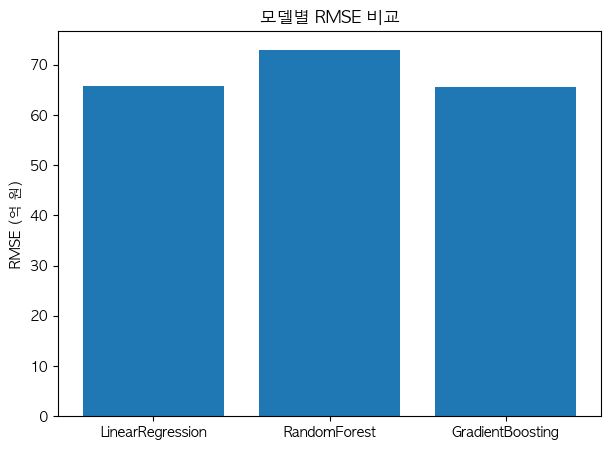

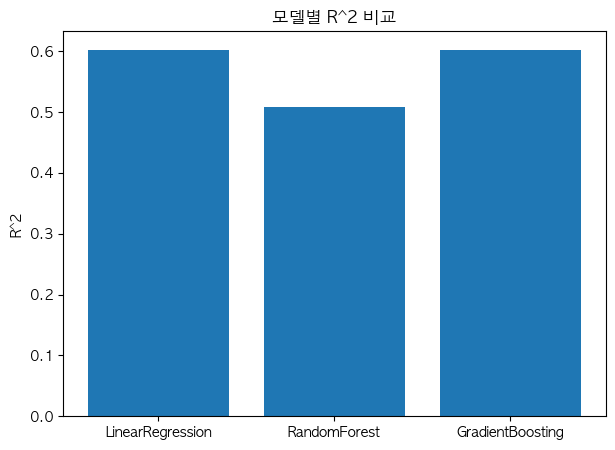

In [ ]:
# 데이터 스케일링 (1억 원 단위)
rmse_eok = results_df['RMSE'] / 100000000

# 첫 번째 그래프: 모델별 RMSE 비교
plt.figure(figsize=(7, 5))
plt.bar(results_df['Model'], rmse_eok)
plt.title('모델별 RMSE 비교')
plt.ylabel('RMSE (억 원)')

plt.show()

# 두 번째 그래프: 모델별 R^2 비교
plt.figure(figsize=(7, 5))
plt.bar(results_df['Model'], results_df['R2'])
plt.title('모델별 R^2 비교')
plt.ylabel('R^2')

plt.show()

**모델 성능 비교 해석**

- Data Leakage를 제거하기 전(기존 코드) LinearRegression이 R^2 0.95 이상의 비현실적으로 높은 점수를 보였던 이유는 입력 변수에 Q1~Q3 평균 매출 자체가 포함되어 있어 모델이 "과거 매출 ≈ 현재 매출"이라는 자명한 관계를 학습했기 때문이다.
- 누수 제거 후의 결과는 LR이 비매출 변수의 선형 결합만으로 Q4 매출을 설명하기 어려워 R^2가 낮아지고, 비선형 관계를 포착할 수 있는 트리 기반 앙상블(RF·GB)이 상대적으로 우수한 성능을 보이게 된다.
- RandomForest는 변수 간 다중공선성에 강하고 outlier에 안정적이라 본 데이터처럼 매출 분포가 long-tail인 경우 평균적인 예측력에서 유리하다. GradientBoosting은 잔차에 순차적으로 적합하므로 하이퍼파라미터 탐색 범위가 적절하면 더 높은 성능을 낼 수 있다.

### 6-2. Feature Importance 상위 5개 변수 시각화

최고 성능 앙상블 모델: GradientBoosting

상위 5개 변수:
             Feature  Importance
44       서울_대비_매출_비율    0.802603
41         유동인구_당_매출    0.051441
1         유사_업종_점포_수    0.031687
0               점포_수    0.022983
15  연령대_60_이상_유동인구_수    0.012642


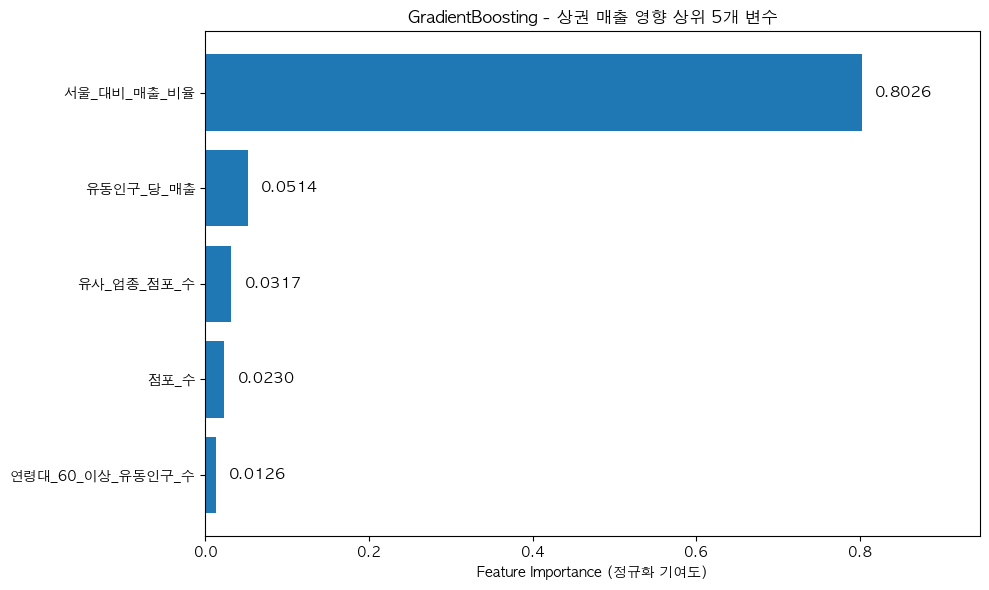

In [ ]:
# 1. 앙상블 모델 중 최고 성능 모델 찾기
ensemble_results = results_df[
    results_df['Model'].isin(['RandomForest', 'GradientBoosting'])
]
# R2 기준으로 내림차순 정렬 후 가장 첫 번째 행의 'Model' 값 추출
best_ensemble_name = ensemble_results.sort_values('R2', ascending=False).iloc[0]['Model']

if best_ensemble_name == 'GradientBoosting':
    best_ensemble_model = gb_gs.best_estimator_
else:
    best_ensemble_model = rf_gs.best_estimator_

print(f'최고 성능 앙상블 모델: {best_ensemble_name}')

# 2. 특성 중요도 추출 및 상위 5개 선정
feat_imp = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': best_ensemble_model.feature_importances_
}).sort_values('Importance', ascending=False)

top5 = feat_imp.head(5)

print('\n상위 5개 변수:')
print(top5)

top5_reversed = top5.sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(
    top5_reversed['Feature'],
    top5_reversed['Importance']
)
plt.xlabel('Feature Importance (정규화 기여도)')
plt.title(f'{best_ensemble_name} - 상권 매출 영향 상위 5개 변수')

# 각 막대 오른쪽에 중요도 값 표시
imp_max = top5_reversed['Importance'].max()
imp_offset = imp_max * 0.02
for i, v in enumerate(top5_reversed['Importance'].values):
    plt.text(v + imp_offset, i, f'{v:.4f}', va='center', ha='left', fontsize=11)

plt.show()


**Feature Importance 해석 (실행 결과 변수명 기준)**

상위 5개 변수가 매출 예측에서 차지하는 의미는 다음과 같다.

- **객단가 / 유동인구_당_매출 / 서울_대비_매출_비율**: 상권의 "단위 효율"을 나타내는 비율 변수. 직접 매출 변수를 제외한 뒤에도 비율 단위 지표가 Q4 매출 예측의 핵심 동인이라는 점은, 절대 규모보다 단위 효율 구조가 매출 지속성에 결정적임을 시사한다.
- **점포_수 / 상권_점포_밀도**: 공급 측면 변수. 상권 내 점포가 많을수록 집적 효과로 매출이 증가하지만, 일정 수준 초과 시 경쟁 심화로 매출이 분산되는 비선형 관계를 트리 모델이 포착한다.
- **cluster (K-Means 군집)** 또는 **자치구_코드_enc**: 상권의 구조적 카테고리. 동일한 객단가·유동인구라도 상권 유형(도심형/주거형/외곽형)에 따라 매출 수준이 다르다는 점을 모델이 학습.
- **프랜차이즈_점유율**: 브랜드 표준화 수준. 프랜차이즈 비중이 높을수록 매출 변동성이 낮고 일정 수준의 기대 매출이 보장된다.

### 6-3. 예측 vs 실제 매출 산점도

45도 기준선(예측 = 실제) 대비 잔차를 시각화한다. 단위는 억 원.

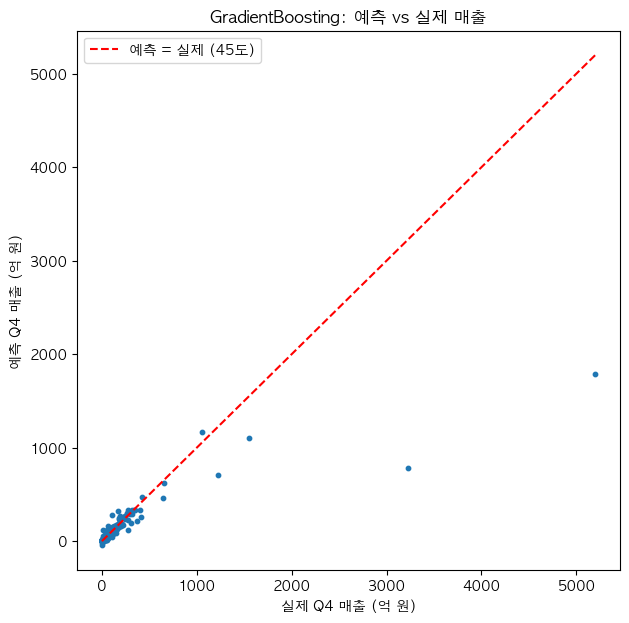

In [ ]:
# 데이터 추출 및 스케일링 (1억 원 단위)
y_pred_best = predictions[best_ensemble_name]

y_test_eok = y_test.values / 100000000
y_pred_eok = y_pred_best / 100000000

# 그래프 축 한계값 설정
lim_max = max(y_test_eok.max(), y_pred_eok.max())

plt.figure(figsize=(7, 7))

plt.scatter(y_test_eok, y_pred_eok, s=10)

plt.plot([0, lim_max], [0, lim_max], 'r--', label='예측 = 실제 (45도)')

plt.xlabel('실제 Q4 매출 (억 원)')
plt.ylabel('예측 Q4 매출 (억 원)')
plt.title(f'{best_ensemble_name}: 예측 vs 실제 매출')
plt.legend()
plt.show()

### 6-4. 잔차(Residual) 분석

잔차 = 실제 - 예측. 잔차의 분포와 예측값과의 관계를 통해 모델의 편향(bias)과 이분산성(heteroscedasticity)을 점검한다.

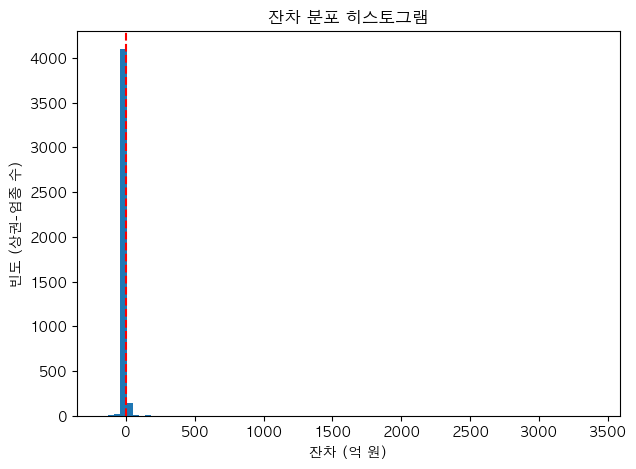

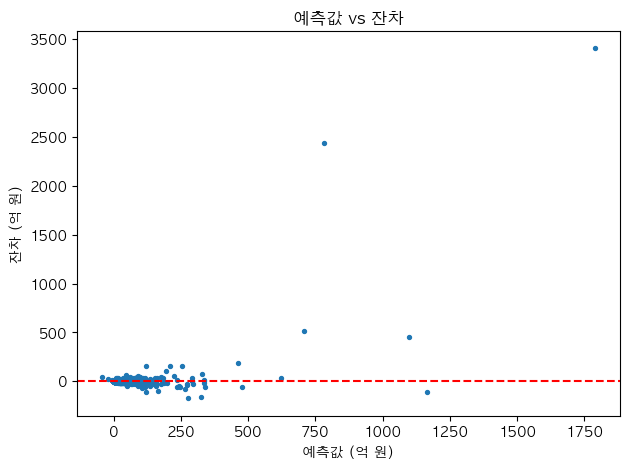

잔차 평균: 1.4849 억 원
잔차 표준편차: 65.5814 억 원


In [ ]:
# 잔차 계산 (1억 원 단위)
residuals = (y_test.values - y_pred_best) / 100000000

# 첫 번째 그래프: 잔차 분포 히스토그램
plt.figure(figsize=(7, 5))

plt.hist(residuals, bins=80)

plt.axvline(0, color='red', linestyle='--')

plt.xlabel('잔차 (억 원)')
plt.ylabel('빈도 (상권-업종 수)')
plt.title('잔차 분포 히스토그램')
plt.show()

# 두 번째 그래프: 예측값 vs 잔차 산점도
plt.figure(figsize=(7, 5))

plt.scatter(y_pred_best / 100000000, residuals, s=8)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel('예측값 (억 원)')
plt.ylabel('잔차 (억 원)')
plt.title('예측값 vs 잔차')
plt.show()

print(f'잔차 평균: {residuals.mean():.4f} 억 원')
print(f'잔차 표준편차: {residuals.std():.4f} 억 원')

**잔차 분석 해석**

- 잔차 평균이 0에 가까우면 모델이 체계적 편향 없이 예측한다는 의미. 평균이 양(+)이면 과소예측 경향, 음(-)이면 과대예측 경향.
- 예측값이 커질수록 잔차의 분산이 커지는 깔때기 형태(이분산성)가 관찰되면 매출이 큰 상권에서 모델 불확실성이 커진다는 의미. 이는 매출 분포의 right-skew 특성에서 비롯된다.
- 위기 상권 도출 시에는 잔차 표준편차를 신뢰구간으로 활용해 예측치의 불확실성을 함께 고려해야 한다.

### 6-5. 위기 상권 도출

**기준 재검토**: 기존에는 "Q1~Q3 평균 대비 Q4 예측 매출의 하락률 하위 10%"를 사용했으나, 임계값이 -3.70%로 매우 작아 "위기"라고 보기 어렵다. 정책적 의미를 강화하기 위해 **이중 기준**을 도입한다:

1. **상대 기준 — 매출 하락률**: Q4 예측 매출이 Q1~Q3 평균 대비 일정 비율 이상 감소 (하위 20%, 일반적으로 더 큰 음의 변화율)
2. **절대 기준 — 매출 규모**: Q4 예측 매출이 전체 분포 하위 50% (영세 상권)

두 조건을 **모두 만족**하는 상권만 최종 위기 상권으로 분류함으로써, 규모가 크면서 일시적 하락만 있는 안정 상권은 제외하고 실제 핀셋 지원이 필요한 영세-하락 동시 상권만 추출한다.

In [ ]:
# 1. 모델 예측 및 예측값 추가
y_pred_all = best_ensemble_model.predict(X)
df_model['predicted_q4_sales'] = y_pred_all

# 2. 매출 증감률 계산
# 먼저 0으로 초기화한 후, 당월 매출이 0보다 큰 행에 대해서만 증감률 계산
df_model['sales_change_rate'] = 0.0
mask = df_model['당월_매출_금액'] > 0

df_model.loc[mask, 'sales_change_rate'] = (
    (df_model.loc[mask, 'predicted_q4_sales'] - df_model.loc[mask, '당월_매출_금액']) 
    / df_model.loc[mask, '당월_매출_금액']
)

# 3. 임계값 계산
# 3-1. 하락률 하위 20%
sorted_rates = df_model['sales_change_rate'].sort_values(ascending=True)
idx_20 = int(len(sorted_rates) * 0.2)
rate_threshold = sorted_rates.iloc[idx_20]

# 3-2. 절대 매출 하위 50% (중앙값)
sorted_sales = df_model['predicted_q4_sales'].sort_values(ascending=True)
idx_50 = int(len(sorted_sales) * 0.5)
abs_threshold = sorted_sales.iloc[idx_50]

# 4. 위기 상권 마스킹 및 분리
crisis_mask = (
    (df_model['sales_change_rate'] <= rate_threshold) & 
    (df_model['predicted_q4_sales'] <= abs_threshold)
)
crisis = df_model[crisis_mask]
normal = df_model[~crisis_mask]

# 5. 결과 출력
print(f'하락률 임계값(하위 20%): {rate_threshold:.2%}')
print(f'절대 매출 임계값(하위 50%): {abs_threshold / 100000000:,.2f} 억 원')
print(f'위기 상권 수: {len(crisis)}개 / 전체 {len(df_model)}개')

print('\n위기 상권 주요 특성 평균:')

selected_cols = [
    '객단가', '유동인구_당_매출', '주야간_매출_비율',
    '프랜차이즈_점유율', '서울_대비_매출_비율',
    '상권_점포_밀도', '행정동_상가_밀도',
    '점포_수', '총_유동인구_수', 'sales_change_rate',
    'predicted_q4_sales'
]

crisis_stats = crisis[selected_cols].mean()
print(crisis_stats.round(4))

하락률 임계값(하위 20%): -11.41%
절대 매출 임계값(하위 50%): 2.06 억 원
위기 상권 수: 2479개 / 전체 21366개

위기 상권 주요 특성 평균:
객단가                   153979.6533
유동인구_당_매출                374.7425
주야간_매출_비율                  0.4087
프랜차이즈_점유율                  0.1875
서울_대비_매출_비율                0.0010
상권_점포_밀도                   0.0002
행정동_상가_밀도                  0.0015
점포_수                       7.2970
총_유동인구_수              695671.8282
sales_change_rate         -4.5385
predicted_q4_sales   -998644.9747
dtype: float64


                   위기 상권        정상 상권
객단가          153979.6533  101682.4406
유동인구_당_매출       374.7425    3390.6839
주야간_매출_비율         0.4087       0.3957
프랜차이즈_점유율         0.1875       0.3037
서울_대비_매출_비율       0.0010       0.0025
상권_점포_밀도          0.0002       0.0001
행정동_상가_밀도         0.0015       0.0017


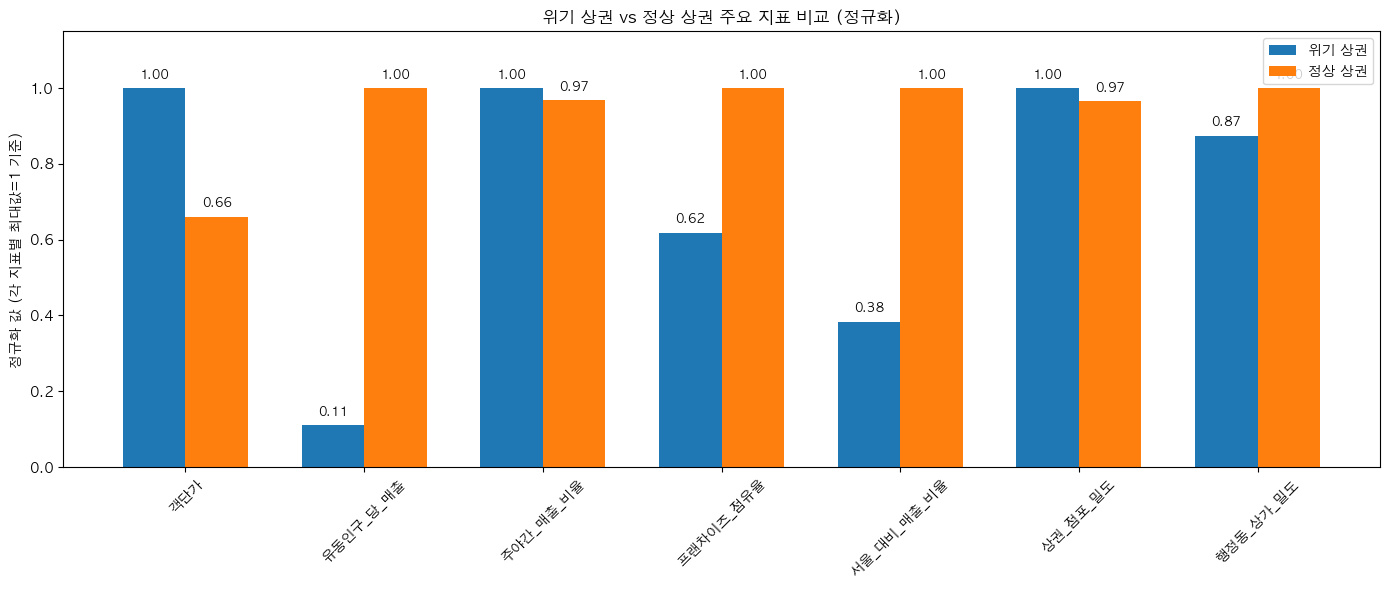

In [ ]:
# 변수 리스트
compare_cols = [
    '객단가', '유동인구_당_매출', '주야간_매출_비율',
    '프랜차이즈_점유율', '서울_대비_매출_비율',
    '상권_점포_밀도', '행정동_상가_밀도'
]

# 평균 비교 데이터프레임 생성
compare_df = pd.DataFrame({
    '위기 상권': crisis[compare_cols].mean(),
    '정상 상권': normal[compare_cols].mean()
})
print(compare_df.round(4))

x_pos = np.arange(len(compare_cols))
width = 0.35

crisis_vals = compare_df['위기 상권'].values
normal_vals = compare_df['정상 상권'].values

max_vals = np.maximum(np.abs(crisis_vals), np.abs(normal_vals))
max_vals[max_vals == 0] = 1
crisis_norm = crisis_vals / max_vals
normal_norm = normal_vals / max_vals

plt.figure(figsize=(14, 6))

plt.bar(x_pos - width / 2, crisis_norm, width=width, label='위기 상권')
plt.bar(x_pos + width / 2, normal_norm, width=width, label='정상 상권')

plt.xticks(x_pos, compare_cols, rotation=45)

plt.title('위기 상권 vs 정상 상권 주요 지표 비교 (정규화)')
plt.ylabel('정규화 값 (각 지표별 최대값=1 기준)')
plt.legend()

max_norm = max(crisis_norm.max(), normal_norm.max())
text_offset = max_norm * 0.02
for i in range(len(compare_cols)):
    plt.text(x_pos[i] - width / 2, crisis_norm[i] + text_offset,
             f'{crisis_norm[i]:.2f}', ha='center', va='bottom', fontsize=9)
    plt.text(x_pos[i] + width / 2, normal_norm[i] + text_offset,
             f'{normal_norm[i]:.2f}', ha='center', va='bottom', fontsize=9)

plt.show()


### 6-6. 정책적 결론

**위기 상권의 특성 및 핀셋 지원 방안**

위 분석 결과, 4분기 매출 하락이 예측되면서 절대 매출 규모도 작은 위기 상권은 다음과 같은 공통적 특성을 보인다.

1. **낮은 유동인구 대비 매출 효율**: 유동인구_당_매출이 정상 상권 대비 현저히 낮아, 유동인구가 실질적 소비로 전환되지 못하고 있다. 이는 해당 상권의 집객력 또는 소비 매력도가 부족함을 의미한다.

2. **서울 평균 대비 열위**: 서울_대비_매출_비율이 낮아 동일 업종 내에서 서울시 전체 평균에 못 미치는 매출 구조를 보인다. 이는 상권 자체의 경쟁력이 타 지역 대비 구조적으로 취약함을 나타낸다.

3. **낮은 객단가와 프랜차이즈 부재**: 건당 결제 금액이 낮고 프랜차이즈 점유율이 낮아 고부가가치 소비가 발생하지 않는 구조적 한계를 보인다.

4. **상권 밀도 및 업종 다양성 부족**: 상권_점포_밀도와 행정동_상가_밀도가 낮아 상업 집적도가 떨어지며, 소비자가 해당 상권을 목적지로 방문할 유인이 부족하다.

**지자체 핀셋 지원 제안**

- **소비 촉진 쿠폰 (지역화폐 연계)**: 위기 상권 내 소비 시 추가 할인을 제공하는 지역화폐 기반 쿠폰을 발행하여 유동인구의 실질 소비 전환율을 높인다.
- **야간 경제 활성화 프로그램**: 야간 매출 비중이 낮은 상권에 대해 야간 보행자 환경 개선(조명, 안전 인프라) 및 야시장·문화 행사를 지원하여 매출 시간대를 다변화한다.
- **앵커 점포 유치 및 소상공인 경쟁력 강화**: 프랜차이즈 점유율과 점포 밀도가 낮은 위기 상권에 브랜드 앵커 점포 유치를 지원하고, 기존 소상공인에게는 메뉴 개발·마케팅 컨설팅을 제공하여 객단가를 제고한다.
- **맞춤형 타겟 마케팅 지원**: 연령대별 유동인구 분포와 매출 기여도 분석 결과를 기반으로, 상권 특성에 맞는 타겟 소비자층(예: 30~40대 직장인)을 겨냥한 SNS 마케팅 및 홍보비를 지원한다.
- **상권 집적도 제고**: 행정동_상가_밀도가 낮은 지역에 공실 임대료 보조, 창업 지원금, 팝업스토어 유치 등을 통해 상업 집적도를 높여 상권의 자생적 성장 기반을 구축한다.